In [443]:
import pickle

from matplotlib import pyplot as plt
import numpy as np

In [444]:
with open('../data/survival.pkl', 'rb') as f:
    survival = pickle.load(f)

170
150
179
180
168
182
162
175
(1000, 500)
(1000, 500)
(1000, 500)
(1000, 500)
(1000, 500)
(1000, 500)
(1000, 500)
(1000, 500)


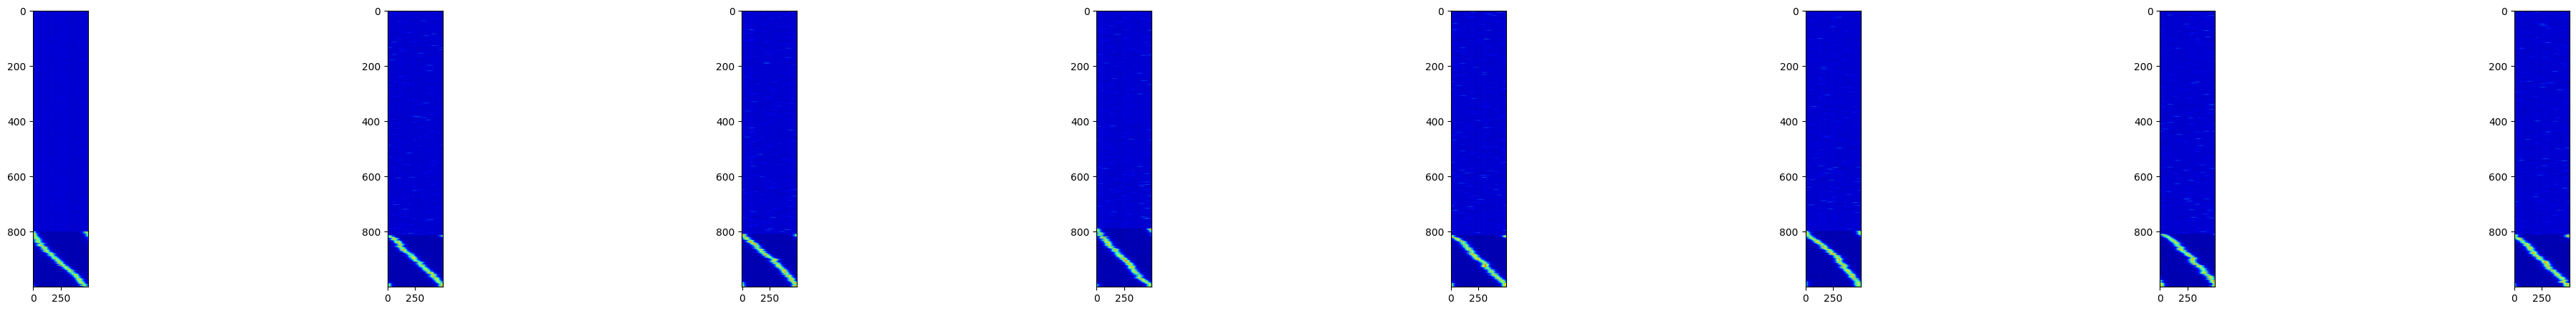

In [445]:
num = 8
fig, ax = plt.subplots(ncols=num, figsize=(50, 5))

vmin = 0
vmax = 40
cmap = "jet"
masks = []


for i in range(num):
    
    m = survival[i]['rate_avg'].T[survival[0]['sorting']].max(axis=1) > 25
    print(m.sum())
    
    masks.append(m)

for i in range(num):
    
    rate = survival[i]['rate_avg'].T[survival[i]['sorting']]
    print(rate.shape)
    
    #ax[i].imshow(rate[masks[i]], vmin=vmin, vmax=vmax, cmap=cmap, aspect=5) 
    ax[i].imshow(rate, vmin=vmin, vmax=vmax, cmap=cmap, aspect=2.5)
    

In [446]:
mask_PC[0].intersection(mask_PC[1])

{11,
 29,
 55,
 58,
 79,
 89,
 90,
 93,
 95,
 150,
 164,
 166,
 183,
 209,
 222,
 224,
 232,
 235,
 257,
 259,
 260,
 263,
 275,
 337,
 343,
 357,
 366,
 367,
 374,
 378,
 393,
 425,
 435,
 438,
 452,
 473,
 506,
 515,
 526,
 556,
 582,
 586,
 588,
 616,
 619,
 625,
 638,
 642,
 645,
 651,
 669,
 670,
 675,
 706,
 707,
 713,
 717,
 723,
 727,
 731,
 734,
 762,
 771,
 782,
 785,
 811,
 822,
 828,
 850,
 862,
 883,
 889,
 890,
 891,
 894,
 900,
 901,
 902,
 905,
 925,
 928,
 933,
 942,
 949,
 977,
 991}

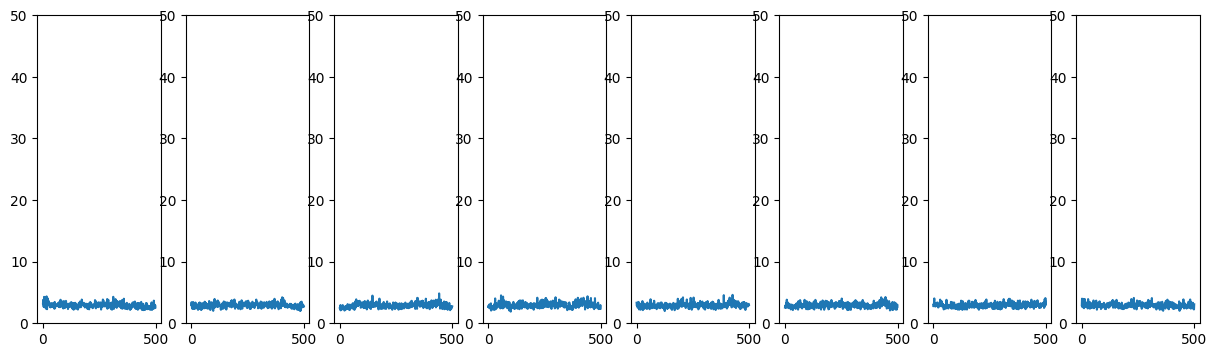

In [447]:
fig, ax = plt.subplots(ncols=num, figsize=(15, 4))
idx = 120
for i in range(num):

    #ax[i].plot(survival[i]['rate_avg'].T[survival[0]['sorting'][idx]])
    ax[i].plot(survival[i]['rate_avg'].T[idx])
    ax[i].set_ylim(0, 50)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


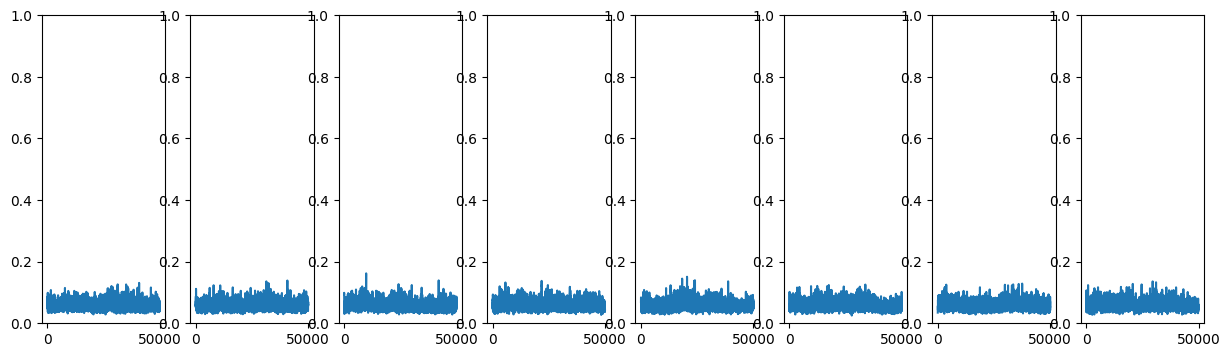

In [448]:
fig, ax = plt.subplots(ncols=num, figsize=(15, 4))
idx = 7
for i in range(num):
    #PPs = survival[i]['PP_onset'][survival[0]['sorting']][idx]
    PPs = survival[i]['PP_onset'][idx]
    print(np.sum(PPs))

    #ax[i].plot(survival[i]['f'][survival[0]['sorting']][idx])
    ax[i].plot(survival[i]['f'][idx])
    ax[i].set_ylim(0, 1)
    times = np.where(PPs > 0)[0]
    for time in times:
        ax[i].axvline(time)

In [449]:
thres = 15
mask_PC = []
num_PCs = []

for i in range(num):
    rates = survival[i]['rate_avg'].T

    mask = rates.max(axis=1) > thres
    mask_PC.append(set(np.where(mask == True)[0].tolist()))
    num_PCs.append(len(mask_PC[i]))

data_model = []

for i in range(1, len(mask_PC)):

    if i == 1:
        ref = mask_PC[i].copy()
    else:
        ref = mask_PC[i].copy().difference(mask_PC[i-1])
    
    data = []
    for j in range(i, len(mask_PC)):
        ref.intersection_update(mask_PC[j])
        data.append(len(ref))

    data_model.append(data)

new = []
old = []

for i in range(len(data_model)):
    
    new.append(data_model[i][0])
    val = 0
    for j in range(0, i):
        val += data_model[j][i - j]

    old.append(val)
    
    

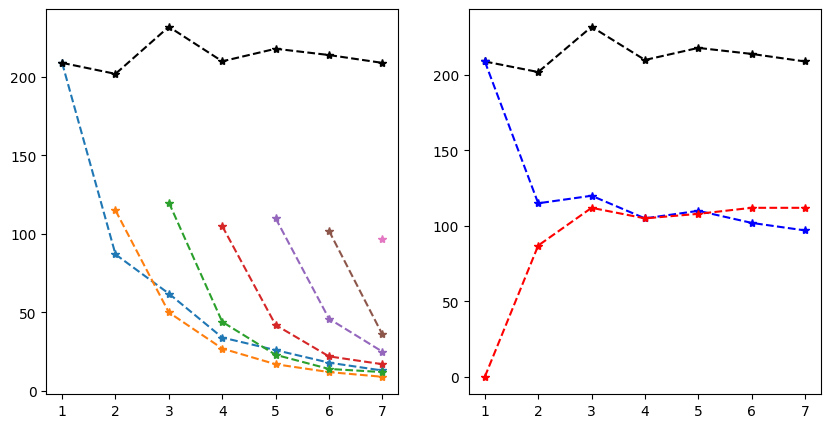

In [450]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

for i, data in enumerate(data_model):
    ax[0].plot(np.arange(i + 1, num), data, marker='*', ls='--')

ax[0].plot(np.arange(1, num), num_PCs[1:], marker='*', ls='--', color='k')

ax[1].plot(np.arange(1, num), num_PCs[1:], marker='*', ls='--', color='k')
ax[1].plot(np.arange(1, num), new, marker='*', ls='--', color='blue')
ax[1].plot(np.arange(1, num), old, marker='*', ls='--', color='red')

#ax[1].plot(np.arange(0, num - 1), np.array(old) + np.array(new), marker='*', ls='--', color='red')

#plt.yscale('log')

In [451]:
data_model

[[209, 87, 62, 34, 26, 18, 13],
 [115, 50, 27, 17, 12, 9],
 [120, 44, 23, 14, 12],
 [105, 42, 22, 17],
 [110, 46, 25],
 [102, 36],
 [97]]

In [452]:
0.9 * np.exp(-0.2)


np.float64(0.7368576777701836)

In [453]:
0.9 * 0.9 * np.exp(-0.05) * 0.9 * np.exp(-0.05) ** 2 *  0.9 * np.exp(-0.05) ** 3 *  0.9 * np.exp(-0.05) ** 3 *  0.9 * np.exp(-0.05) ** 4

np.float64(0.27743652964765125)

In [454]:
rates = survival[i]['rate_avg'].T

In [455]:
import pandas as pd

In [456]:
df_fig2e = pd.read_excel('data_fig2_magee/41593_2025_1986_MOESM3_ESM.xlsx', sheet_name='Fig2e')[1:].values
df_fig2g = pd.read_excel('data_fig2_magee/41593_2025_1986_MOESM3_ESM.xlsx', sheet_name='Fig2g')

In [457]:
f_d_1_fig2e = df_fig2e[:, 1:8]
f_d_2_fig2e = df_fig2e[:, 9:]

data_1 = []
data_2 = []

for i, row in enumerate(f_d_1_fig2e):
    data_1.append(row[i:])

for i, row in enumerate(f_d_2_fig2e):
    data_2.append(row[i:])

[748.0 269.0 137.0 97.0 75.0 53.0 48]
[471.0 198.0 98.0 66.0 46.0 35]
[393.0 168.0 104.0 76.0 57]
[384.0 157.0 82.0 60]
[378.0 172.0 121]
[332.0 158]
[333]
[812.0 284.0 168.0 107.0 81.0 61.0 47]
[461.0 177.0 103.0 70.0 54.0 45]
[427.0 157.0 99.0 59.0 43]
[357.0 136.0 91.0 67]
[353.0 164.0 98]
[372.0 147]
[353]


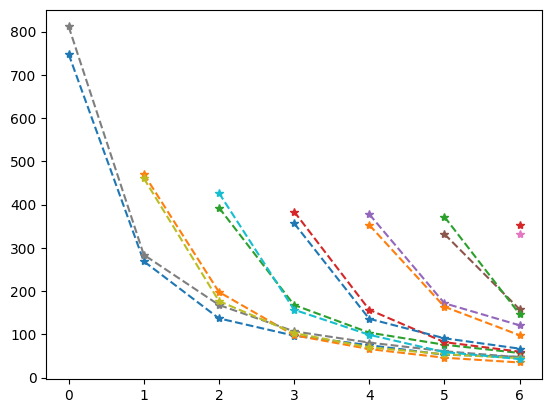

In [458]:
num = 7
for i, data_ in enumerate(data_1):
    print(data_)
    plt.plot(np.arange(i, num), data_, marker='*', ls='--')

for i, data_ in enumerate(data_2
                         ):
    print(data_)
    plt.plot(np.arange(i, num), data_, marker='*', ls='--')

In [459]:
new_1 = []
old_1 = []

for i in range(len(data_1)):
    
    new_1.append(data_1[i][0])
    val = 0
    for j in range(0, i):
        val += data_1[j][i - j]

    old_1.append(val)

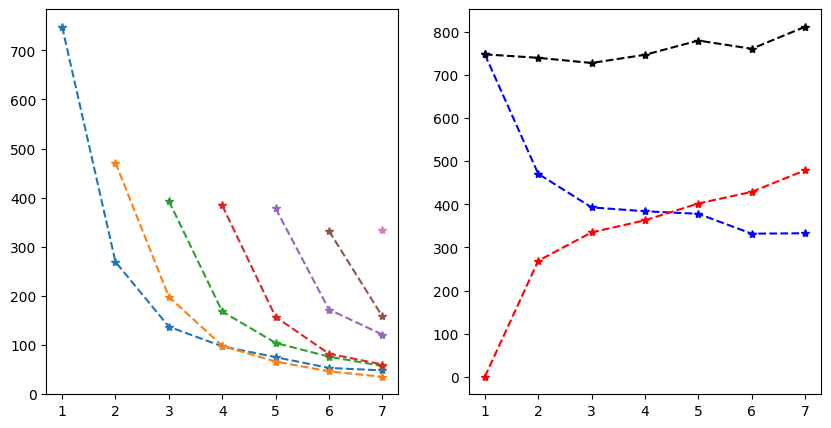

In [460]:
num = 7
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

for i, data_ in enumerate(data_1):
    ax[0].plot(np.arange(i + 1, num  + 1), data_, marker='*', ls='--')

ax[1].plot(np.arange(1, num + 1), new_1, marker='*', ls='--', color='blue')
ax[1].plot(np.arange(1, num + 1), old_1, marker='*', ls='--', color='red')
ax[1].plot(np.arange(1, num + 1), np.array(new_1) + np.array(old_1), marker='*', ls='--', color='k')

In [461]:
1 - np.exp(-3)

np.float64(0.950212931632136)

In [462]:
colors = ['firebrick', 'darkorange', 'chartreuse',  'green', 'cyan', 'blueviolet', 'crimson']

In [463]:
colors = ['firebrick', 'darkorange', 'chartreuse',  'green', 'cyan', 'blueviolet', 'crimson']
mosaic = """
    AAAAAAAA
    ........
    BBBBCCCC
    BBBBCCCC
    BBBBCCCC
    DDDDEEEE
    DDDDEEEE
    DDDDEEEE
    DDDDEEEE
    """

place_filed_tiles = ['B', 'C']
titles = ['Hippocampal Data', 'Model Data']

place_tiles = ['B', 'C', 'D', 'E']

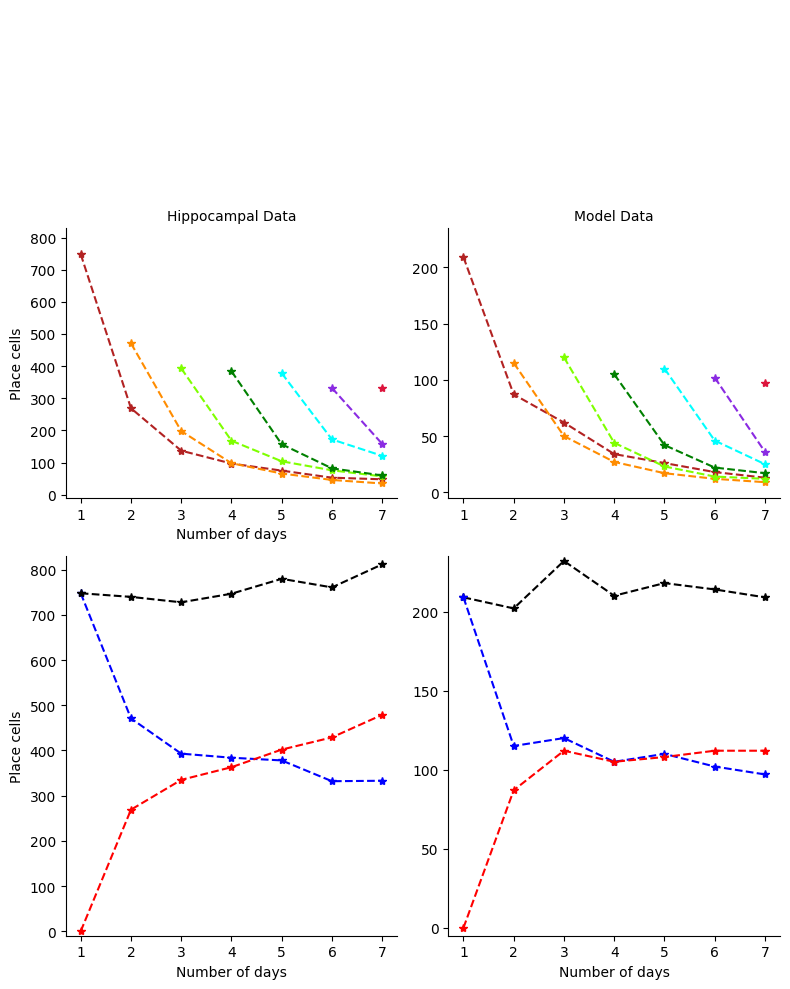

In [467]:
num = 7
num_data = 8
fig = plt.figure(figsize=(8,10))
ax_dict = fig.subplot_mosaic(mosaic)

for (tile, title) in zip(place_filed_tiles, titles):
    ax_dict[tile].set_title(title, fontsize=10)

for tile in place_tiles:
    ax_dict[tile].spines['top'].set_visible(False)
    ax_dict[tile].spines['right'].set_visible(False)

    
for spine in ax_dict['A'].spines.keys():
    ax_dict['A'].spines[spine].set_visible(False)
ax_dict['A'].set_xticks([])
ax_dict['A'].set_yticks([])
    
ax_dict['B'].set_ylim([-10, 830])
ax_dict['B'].set_ylabel('Place cells')

for i, data_ in enumerate(data_1):
    ax_dict['B'].plot(np.arange(i + 1, num  + 1), data_, marker='*', ls='--', color=colors[i])
ax_dict['B'].set_xticks(np.arange(1, num + 1).tolist())
ax_dict['B'].set_xlabel('Number of days')

ax_dict['C'].set_ylim([-5, 235])

for i, data in enumerate(data_model):
    ax_dict['C'].plot(np.arange(i + 1, num_data), data, marker='*', ls='--', color=colors[i])
ax_dict['C'].set_ylim([-5, 235]) 

ax_dict['D'].set_ylim([-10, 830])

ax_dict['D'].plot(np.arange(1, num + 1), new_1, marker='*', ls='--', color='blue')
ax_dict['D'].plot(np.arange(1, num + 1), old_1, marker='*', ls='--', color='red')
ax_dict['D'].plot(np.arange(1, num + 1), np.array(new_1) + np.array(old_1), marker='*', ls='--', color='k')
ax_dict['D'].set_xticks(np.arange(1, num + 1).tolist())
ax_dict['D'].set_xlabel('Number of days')
ax_dict['D'].set_ylabel('Place cells')


ax_dict['E'].plot(np.arange(1, num_data), num_PCs[1:], marker='*', ls='--', color='k')
ax_dict['E'].plot(np.arange(1, num_data), new, marker='*', ls='--', color='blue')
ax_dict['E'].plot(np.arange(1, num_data), old, marker='*', ls='--', color='red')
ax_dict['E'].set_xlabel('Number of days')
ax_dict['E'].set_ylim([-5, 235])

plt.tight_layout()

(array([27., 28., 14., 13.,  7.,  4.,  3.,  1.,  1.,  2.]),
 array([0.00783711, 0.09491788, 0.18199864, 0.26907941, 0.35616018,
        0.44324094, 0.53032171, 0.61740248, 0.70448324, 0.79156401,
        0.87864478]),
 <BarContainer object of 10 artists>)

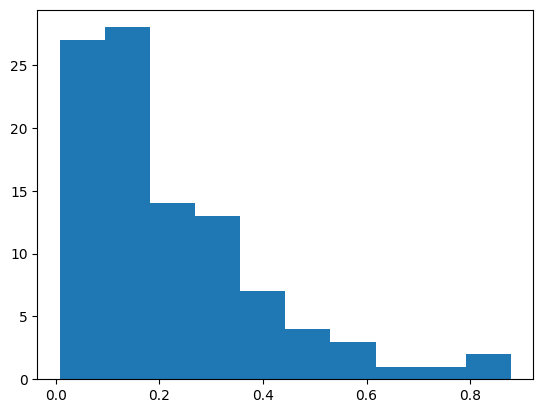

In [403]:
plt.hist(np.random.exponential(0.25, 100))

In [1605]:
vals = np.arange(0.01, 3.5 + 0.01, 0.01)

In [1606]:
for a in ax_dict['A'].spines.keys():
    print(a)

left
right
bottom
top


In [1607]:

shift = 0.001
fac = 1
gamma = 1.
density = 1 /(shift + (fac * vals)) ** gamma + 1/np.abs(vals -1)**0.8
density /= density.sum()
density

/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_35056/535324498.py:4: RuntimeWarning: divide by zero encountered in divide
  density = 1 /(shift + (fac * vals)) ** gamma + 1/np.abs(vals -1)**0.8
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_35056/535324498.py:5: RuntimeWarning: invalid value encountered in divide
  density /= density.sum()


array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., nan,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0

In [1608]:
samples = np.random.choice(vals, size=10000, p=density) / 3.5

ValueError: probabilities contain NaN

(array([29.75      , 13.44642857,  8.51785714,  6.33928571,  5.03571429,
         4.10714286,  3.73214286,  3.14285714,  3.10714286,  2.82142857,
         2.39285714,  2.21428571,  1.94642857,  2.17857143,  2.08928571,
         2.        ,  2.08928571,  1.80357143,  1.60714286,  1.46428571,
         1.25      ,  1.67857143,  1.96428571,  1.91071429,  1.78571429,
         0.69642857,  1.05357143,  1.55357143,  1.75      ,  1.60714286,
         1.64285714,  1.28571429,  1.875     ,  1.60714286,  1.60714286,
         2.03571429,  1.80357143,  1.96428571,  1.98214286,  2.16071429,
         1.91071429,  2.28571429,  2.125     ,  2.76785714,  2.75      ,
         4.        ,  4.01785714,  4.75      ,  6.53571429, 14.42857143]),
 array([0.00285714, 0.00845714, 0.01405714, 0.01965714, 0.02525714,
        0.03085714, 0.03645714, 0.04205714, 0.04765714, 0.05325714,
        0.05885714, 0.06445714, 0.07005714, 0.07565714, 0.08125714,
        0.08685714, 0.09245714, 0.09805714, 0.10365714, 0.109257

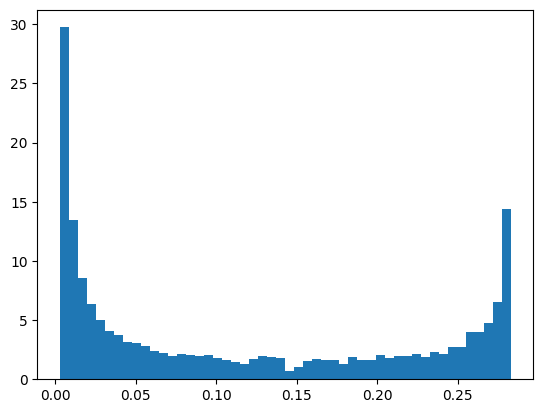

In [1609]:
plt.hist(samples, density=True, bins=50)


In [1610]:
n_s = 100000
samples = np.random.choice(vals, size=n_s, p=density)
(samples > 0.8).sum() / n_s  * 100

ValueError: probabilities contain NaN

In [1611]:
n_s = 100000
samples = np.random.choice(vals, size=n_s, p=density)
(samples < 0.4).sum() / n_s  * 100

ValueError: probabilities contain NaN

In [1612]:
shift = 0.01
fac = 1.
gamma = 0.75
density = 1 /(shift + (fac * vals) ** gamma)
density /= density.sum()
samples = np.random.choice(vals, size=200, p=density)
(samples > 0.8).sum()

np.int64(83)

In [1613]:
(215 - 20) * 11 - 215 * 10

-5

In [1614]:
215 

215

In [637]:
np.exp(-0.15)**5

np.float64(0.4723665527410147)

In [1231]:
50 / 800

0.0625

In [1615]:
len(mask_PC[0].intersection(mask_PC[1]))

58

In [1616]:
 rates = survival[i]['rate_avg'].T

In [1620]:
rates.sum(axis=1).shape

(800,)

In [1621]:
mask = rates.max(axis=1) > thres

In [1623]:
mask.sum()

np.int64(132)

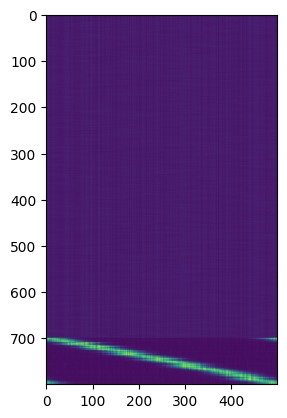

In [1640]:
rate = survival[0]['rate_avg'].T[survival[0]['sorting']]
plt.imshow(rate, vmin=0, vmax=50)

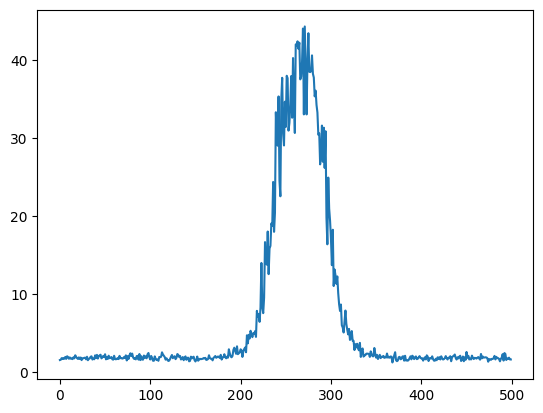

In [1646]:
plt.plot(rate[750])

In [404]:
15.99 / 3.99


4.007518796992481